In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [68]:
## reading our closing files which is combined_weekly_dataset
## reading our predicted label regime_label_k
## reading our predicting labels supervised_predictions

## Read core files
regime_df = pd.read_parquet("regime_labeled_k_combine.parquet")
supervised_predictions = pd.read_parquet("combined_supervised_predictions.parquet")
combined_weekly = pd.read_parquet("combined_weekly_dataset.parquet")

# Make sure indexes are datetime + sorted
regime_df.index = pd.to_datetime(regime_df.index)
supervised_predictions.index = pd.to_datetime(supervised_predictions.index)
combined_weekly.index = pd.to_datetime(combined_weekly.index)

regime_df = regime_df.sort_index()
supervised_predictions = supervised_predictions.sort_index()
combined_weekly = combined_weekly.sort_index()

print("regime_df shape:", regime_df.shape)
print("supervised_predictions shape:", supervised_predictions.shape)
print("combined_weekly shape:", combined_weekly.shape)

print("\nregime_df columns:")
print(regime_df.columns.tolist())

print("\nsupervised_predictions columns:")
print(supervised_predictions.columns.tolist())

print("\ncombined_weekly columns:")
print(combined_weekly.columns.tolist())


regime_df shape: (1055, 27)
supervised_predictions shape: (757, 13)
combined_weekly shape: (1631, 31)

regime_df columns:
['global_vol', 'vol_slope', 'vov', 'SP500_SPY_ret', 'NASDAQ100_QQQ_ret', 'DOW_JONES_ret', 'NASDAQ100_ret', 'NIKKEI_225_ret', 'SHANGHAI_COMPOSITE_ret', 'HANG_SENG_ret', 'TREASURY_BOND_TLT_ret', 'GOLD_GLD_ret', 'usd_index_ret', 'SPY_return', 'QQQ_return', 'SPY_vol_12', 'SPY_vol_4', 'SPY_momentum_12', 'VIX', 'VIX_change', 'TREASURY_10Y', 'TREASURY_2Y', 'yield_spread', 'regime', 'dataset_split', 'regime_name', 'regime_3class']

supervised_predictions columns:
['actual_regime', 'pred_lr', 'pred_rf', 'lr_proba_Opportunity', 'lr_proba_Still Good', 'lr_proba_Stress', 'rf_proba_Opportunity', 'rf_proba_Still Good', 'rf_proba_Stress', 'current_regime', 'current_regime_num', 'target_regime_num', 'raw_cluster']

combined_weekly columns:
['SHANGHAI_COMPOSITE', 'CVX', 'usd_index', 'GOLD_GLD', 'REAL_ESTATE_IYR', 'SLB', 'SILVER_SLV', 'CRUDE_OIL_USO', 'MATERIALS_XLB', 'ENERGY_XLE', '

In [69]:
regime_df.index = pd.to_datetime(regime_df.index, errors="coerce")
supervised_predictions.index = pd.to_datetime(supervised_predictions.index, errors="coerce")
combined_weekly.index = pd.to_datetime(combined_weekly.index, errors="coerce")

regime_df = regime_df[~regime_df.index.isna()].copy()
supervised_predictions = supervised_predictions[~supervised_predictions.index.isna()].copy()
combined_weekly = combined_weekly[~combined_weekly.index.isna()].copy()

regime_df = regime_df[~regime_df.index.duplicated(keep="first")].sort_index()
supervised_predictions = supervised_predictions[~supervised_predictions.index.duplicated(keep="first")].sort_index()
combined_weekly = combined_weekly[~combined_weekly.index.duplicated(keep="first")].sort_index()

print("regime_df date range:", regime_df.index.min(), "to", regime_df.index.max())
print("supervised_predictions date range:", supervised_predictions.index.min(), "to", supervised_predictions.index.max())
print("combined_weekly date range:", combined_weekly.index.min(), "to", combined_weekly.index.max())

regime_df date range: 2004-11-26 00:00:00 to 2026-03-06 00:00:00
supervised_predictions date range: 2011-01-07 00:00:00 to 2026-02-13 00:00:00
combined_weekly date range: 1995-01-06 00:00:00 to 2026-04-03 00:00:00


In [70]:
backtest_df = combined_weekly.copy()

# Keep only useful unsupervised columns
unsup_cols = [col for col in ["regime", "regime_3class", "regime_name"] if col in regime_df.columns]
backtest_df = backtest_df.join(regime_df[unsup_cols], how="left")

# Add supervised predictions
backtest_df = backtest_df.join(supervised_predictions, how="left")

# Final sort
backtest_df = backtest_df.sort_index()

print("backtest_df shape:", backtest_df.shape)
print("backtest_df date range:", backtest_df.index.min(), "to", backtest_df.index.max())

backtest_df shape: (1631, 47)
backtest_df date range: 1995-01-06 00:00:00 to 2026-04-03 00:00:00


In [71]:
# Unsupervised sample:
# keep rows where observed regime label exists
unsup_bt = backtest_df.dropna(subset=["regime_name"]).copy()

# Supervised sample:
# keep rows where supervised predictions exist
sup_bt = backtest_df.dropna(subset=["actual_regime", "pred_lr", "pred_rf"]).copy()

print("Unsupervised backtest shape:", unsup_bt.shape)
print("Supervised backtest shape:", sup_bt.shape)

print("\nUnsupervised date range:",
      unsup_bt.index.min().date(), "to", unsup_bt.index.max().date())

print("Supervised date range:",
      sup_bt.index.min().date(), "to", sup_bt.index.max().date())

# Strategy signals
unsup_bt["signal_unsup"] = unsup_bt["regime_name"].shift(1)
sup_bt["signal_lr"] = sup_bt["pred_lr"]
sup_bt["signal_rf"] = sup_bt["pred_rf"]

print("\nUnsupervised signal counts:")
print(unsup_bt["signal_unsup"].value_counts(dropna=False))

print("\nLogistic signal counts:")
print(sup_bt["signal_lr"].value_counts(dropna=False))

print("\nRandom Forest signal counts:")
print(sup_bt["signal_rf"].value_counts(dropna=False))

print("\nPreview supervised signals:")
print(
    sup_bt[["current_regime", "actual_regime", "signal_lr", "signal_rf"]].head(10)
)

Unsupervised backtest shape: (1055, 47)
Supervised backtest shape: (757, 47)

Unsupervised date range: 2004-11-26 to 2026-03-06
Supervised date range: 2011-01-07 to 2026-02-13

Unsupervised signal counts:
signal_unsup
Low_Vol     750
Mid_Vol     270
High_Vol     34
None          1
Name: count, dtype: int64

Logistic signal counts:
signal_lr
Opportunity    542
Still Good     164
Stress          51
Name: count, dtype: int64

Random Forest signal counts:
signal_rf
Opportunity    552
Still Good     191
Stress          14
Name: count, dtype: int64

Preview supervised signals:
           current_regime actual_regime    signal_lr    signal_rf
2011-01-07    Opportunity   Opportunity  Opportunity  Opportunity
2011-01-14    Opportunity   Opportunity  Opportunity  Opportunity
2011-01-21    Opportunity   Opportunity   Still Good  Opportunity
2011-01-28    Opportunity   Opportunity   Still Good  Opportunity
2011-02-04    Opportunity   Opportunity   Still Good  Opportunity
2011-02-11    Opportunity 

In [72]:
# Standardize unsupervised labels to match supervised naming
unsup_label_map = {
    "Low_Vol": "Opportunity",
    "Mid_Vol": "Still Good",
    "High_Vol": "Stress"
}

unsup_bt["signal_unsup_std"] = unsup_bt["signal_unsup"].map(unsup_label_map)

print("\nStandardized unsupervised signal counts:")
print(unsup_bt["signal_unsup_std"].value_counts(dropna=False))


Standardized unsupervised signal counts:
signal_unsup_std
Opportunity    750
Still Good     270
Stress          34
NaN              1
Name: count, dtype: int64


In [73]:
# testing on a few tickers
price_cols = {
    "SPY": "SP500_SPY",
    "QQQ": "NASDAQ100_QQQ",
    "TLT": "TREASURY_BOND_TLT",
    "GLD": "GOLD_GLD"
}

returns_df = pd.DataFrame(index=backtest_df.index)

for asset_name, col in price_cols.items():
    if col in backtest_df.columns:
        returns_df[f"{asset_name}_return"] = backtest_df[col].pct_change()
    else:
        print(f"Warning: {col} not found in backtest_df")

print("\nReturn columns created:")
print(returns_df.columns.tolist())

print("\nReturns preview:")
print(returns_df.head())

# Attach returns into master dataframe
backtest_df = backtest_df.join(returns_df, how="left")

# Rebuild strategy subsets so they now include returns
unsup_bt = backtest_df.dropna(subset=["regime_name"]).copy()
sup_bt = backtest_df.dropna(subset=["actual_regime", "pred_lr", "pred_rf"]).copy()

# Recreate signals after rebuilding
unsup_bt["signal_unsup"] = unsup_bt["regime_name"].shift(1)

unsup_label_map = {
    "Low_Vol": "Opportunity",
    "Mid_Vol": "Still Good",
    "High_Vol": "Stress"
}
unsup_bt["signal_unsup_std"] = unsup_bt["signal_unsup"].map(unsup_label_map)

sup_bt["signal_lr"] = sup_bt["pred_lr"]
sup_bt["signal_rf"] = sup_bt["pred_rf"]

# Drop rows with missing signals
unsup_bt = unsup_bt.dropna(subset=["signal_unsup_std"]).copy()
sup_bt = sup_bt.dropna(subset=["signal_lr", "signal_rf"]).copy()

print("\nunsup_bt return columns present:")
print([c for c in unsup_bt.columns if "_return" in c])

print("\nsup_bt return columns present:")
print([c for c in sup_bt.columns if "_return" in c])


Return columns created:
['SPY_return', 'QQQ_return', 'TLT_return', 'GLD_return']

Returns preview:
            SPY_return  QQQ_return  TLT_return  GLD_return
1995-01-06         NaN         NaN         NaN         NaN
1995-01-13    0.014929         NaN         NaN         NaN
1995-01-20   -0.004011         NaN         NaN         NaN
1995-01-27    0.012084         NaN         NaN         NaN
1995-02-03    0.019570         NaN         NaN         NaN

unsup_bt return columns present:
['SPY_return', 'QQQ_return', 'TLT_return', 'GLD_return']

sup_bt return columns present:
['SPY_return', 'QQQ_return', 'TLT_return', 'GLD_return']


In [74]:
# Allocation Rules
# testing theory to see results

allocation_map = {
    "Opportunity": {"SPY": 0.60, "QQQ": 0.20, "TLT": 0.20, "GLD": 0.00},
    "Still Good": {"SPY": 0.40, "QQQ": 0.20, "TLT": 0.30, "GLD": 0.10},
    "Stress": {"SPY": 0.10, "QQQ": 0.00, "TLT": 0.70, "GLD": 0.20}
}

def get_weights(regime):
    if pd.isna(regime):
        return {k: np.nan for k in ["SPY", "QQQ", "TLT", "GLD"]}
    if regime not in allocation_map:
        raise ValueError(f"Regime {regime} not found in allocation map")
    return allocation_map[regime]

# Unsupervised weights
weights_unsup = unsup_bt["signal_unsup_std"].map(get_weights).apply(pd.Series)
weights_unsup = weights_unsup.add_prefix("w_unsup_")

# Logistic weights
weights_lr = sup_bt["signal_lr"].map(get_weights).apply(pd.Series)
weights_lr = weights_lr.add_prefix("w_lr_")

# Random Forest weights
weights_rf = sup_bt["signal_rf"].map(get_weights).apply(pd.Series)
weights_rf = weights_rf.add_prefix("w_rf_")

# Attach back to each strategy dataframe
unsup_bt = pd.concat([unsup_bt, weights_unsup], axis=1)
sup_bt = pd.concat([sup_bt, weights_lr, weights_rf], axis=1)

# Weight checks
print("Unsupervised weight sums:")
print(weights_unsup.sum(axis=1).value_counts().head())

print("\nLogistic weight sums:")
print(weights_lr.sum(axis=1).value_counts().head())

print("\nRandom Forest weight sums:")
print(weights_rf.sum(axis=1).value_counts().head())

print("\nUnsupervised columns:")
print([c for c in unsup_bt.columns if c.startswith("w_unsup_")])

print("\nSupervised columns:")
print([c for c in sup_bt.columns if c.startswith("w_lr_") or c.startswith("w_rf_")])

Unsupervised weight sums:
1.0    784
1.0    270
Name: count, dtype: int64

Logistic weight sums:
1.0    593
1.0    164
Name: count, dtype: int64

Random Forest weight sums:
1.0    566
1.0    191
Name: count, dtype: int64

Unsupervised columns:
['w_unsup_SPY', 'w_unsup_QQQ', 'w_unsup_TLT', 'w_unsup_GLD']

Supervised columns:
['w_lr_SPY', 'w_lr_QQQ', 'w_lr_TLT', 'w_lr_GLD', 'w_rf_SPY', 'w_rf_QQQ', 'w_rf_TLT', 'w_rf_GLD']


In [75]:
# Strategy returns

# Fill GLD return if needed
for df in [unsup_bt, sup_bt]:
    if "GLD_return" not in df.columns:
        df["GLD_return"] = 0.0
    else:
        df["GLD_return"] = df["GLD_return"].fillna(0.0)

# Unsupervised strategy return
unsup_bt["strategy_return_unsup"] = (
    unsup_bt["w_unsup_SPY"] * unsup_bt["SPY_return"] +
    unsup_bt["w_unsup_QQQ"] * unsup_bt["QQQ_return"] +
    unsup_bt["w_unsup_TLT"] * unsup_bt["TLT_return"] +
    unsup_bt["w_unsup_GLD"] * unsup_bt["GLD_return"]
)

# Logistic strategy return
sup_bt["strategy_return_lr"] = (
    sup_bt["w_lr_SPY"] * sup_bt["SPY_return"] +
    sup_bt["w_lr_QQQ"] * sup_bt["QQQ_return"] +
    sup_bt["w_lr_TLT"] * sup_bt["TLT_return"] +
    sup_bt["w_lr_GLD"] * sup_bt["GLD_return"]
)

# Random Forest strategy return
sup_bt["strategy_return_rf"] = (
    sup_bt["w_rf_SPY"] * sup_bt["SPY_return"] +
    sup_bt["w_rf_QQQ"] * sup_bt["QQQ_return"] +
    sup_bt["w_rf_TLT"] * sup_bt["TLT_return"] +
    sup_bt["w_rf_GLD"] * sup_bt["GLD_return"]
)

# Benchmarks
unsup_bt["benchmark_spy"] = unsup_bt["SPY_return"]
unsup_bt["benchmark_80_20"] = 0.80 * unsup_bt["SPY_return"] + 0.20 * unsup_bt["TLT_return"]

sup_bt["benchmark_spy"] = sup_bt["SPY_return"]
sup_bt["benchmark_80_20"] = 0.80 * sup_bt["SPY_return"] + 0.20 * sup_bt["TLT_return"]

print("\nUnsupervised return preview:")
print(
    unsup_bt[["strategy_return_unsup", "benchmark_spy", "benchmark_80_20"]].head()
)

print("\nSupervised return preview:")
print(
    sup_bt[["strategy_return_lr", "strategy_return_rf", "benchmark_spy", "benchmark_80_20"]].head()
)


Unsupervised return preview:
            strategy_return_unsup  benchmark_spy  benchmark_80_20
2004-12-03               0.008232       0.007605         0.005061
2004-12-10               0.002631       0.000671         0.003761
2004-12-17               0.002754       0.005650         0.004295
2004-12-24               0.007790       0.011135         0.008548
2004-12-31               0.001972       0.000828         0.001333

Supervised return preview:
            strategy_return_lr  strategy_return_rf  benchmark_spy  \
2011-01-07            0.008049            0.008049       0.011054   
2011-01-14            0.013134            0.013134       0.016989   
2011-01-21           -0.009805           -0.009644      -0.007193   
2011-01-28           -0.001107           -0.001984      -0.005064   
2011-02-04            0.008593            0.015948       0.026856   

            benchmark_80_20  
2011-01-07         0.005082  
2011-01-14         0.012487  
2011-01-21        -0.006451  
2011-01-28 

In [80]:
# Performance Functions

def cumulative_growth(return_series, initial_value=1.0):
    return_series = return_series.dropna()
    return initial_value * (1 + return_series).cumprod()

def annualized_return(return_series, periods_per_year=52):
    return_series = return_series.dropna()
    n_periods = len(return_series)
    if n_periods == 0:
        return np.nan
    compounded = (1 + return_series).prod()
    return compounded ** (periods_per_year / n_periods) - 1

def annualized_volatility(return_series, periods_per_year=52):
    return_series = return_series.dropna()
    if len(return_series) == 0:
        return np.nan
    return return_series.std() * np.sqrt(periods_per_year)

def sharpe_ratio(return_series, periods_per_year=52, risk_free_rate=0.0):
    return_series = return_series.dropna()
    ann_ret = annualized_return(return_series, periods_per_year)
    ann_vol = annualized_volatility(return_series, periods_per_year)
    if pd.isna(ann_vol) or ann_vol == 0:
        return np.nan
    return (ann_ret - risk_free_rate) / ann_vol

def max_drawdown(return_series):
    return_series = return_series.dropna()
    if len(return_series) == 0:
        return np.nan
    growth = (1 + return_series).cumprod()
    peak = growth.cummax()
    drawdown = growth / peak - 1
    return drawdown.min()

def summarize_performance(return_series, name, periods_per_year=52):
    return {
        "Strategy": name,
        "Annualized Return": annualized_return(return_series, periods_per_year),
        "Annualized Volatility": annualized_volatility(return_series, periods_per_year),
        "Sharpe Ratio": sharpe_ratio(return_series, periods_per_year),
        "Max Drawdown": max_drawdown(return_series)
    }

In [82]:
# align test dates to only those that actually exist in backtest_df
# Unsupervised strategy summary
unsup_summary = pd.DataFrame([
    summarize_performance(unsup_bt["strategy_return_unsup"], "Unsupervised Regime Strategy"),
    summarize_performance(unsup_bt["benchmark_spy"], "Buy & Hold SPY (Unsup Window)"),
    summarize_performance(unsup_bt["benchmark_80_20"], "80/20 SPY-TLT (Unsup Window)")
])

# Supervised strategy summary
sup_summary = pd.DataFrame([
    summarize_performance(sup_bt["strategy_return_lr"], "Logistic Regime Strategy"),
    summarize_performance(sup_bt["strategy_return_rf"], "Random Forest Regime Strategy"),
    summarize_performance(sup_bt["benchmark_spy"], "Buy & Hold SPY (Sup Window)"),
    summarize_performance(sup_bt["benchmark_80_20"], "80/20 SPY-TLT (Sup Window)")
])

print("\nPerformance Summary — Unsupervised")
print(unsup_summary)

print("\nPerformance Summary — Supervised")
print(sup_summary)


Performance Summary — Unsupervised
                        Strategy  Annualized Return  Annualized Volatility  \
0   Unsupervised Regime Strategy           0.118400               0.112177   
1  Buy & Hold SPY (Unsup Window)           0.119801               0.170133   
2   80/20 SPY-TLT (Unsup Window)           0.109591               0.131838   

   Sharpe Ratio  Max Drawdown  
0      1.055468     -0.256113  
1      0.704156     -0.413713  
2      0.831252     -0.296071  

Performance Summary — Supervised
                        Strategy  Annualized Return  Annualized Volatility  \
0       Logistic Regime Strategy           0.170214               0.104519   
1  Random Forest Regime Strategy           0.139219               0.113208   
2    Buy & Hold SPY (Sup Window)           0.132914               0.161942   
3     80/20 SPY-TLT (Sup Window)           0.117681               0.126865   

   Sharpe Ratio  Max Drawdown  
0      1.628546     -0.202660  
1      1.229758     -0.249583  
2 

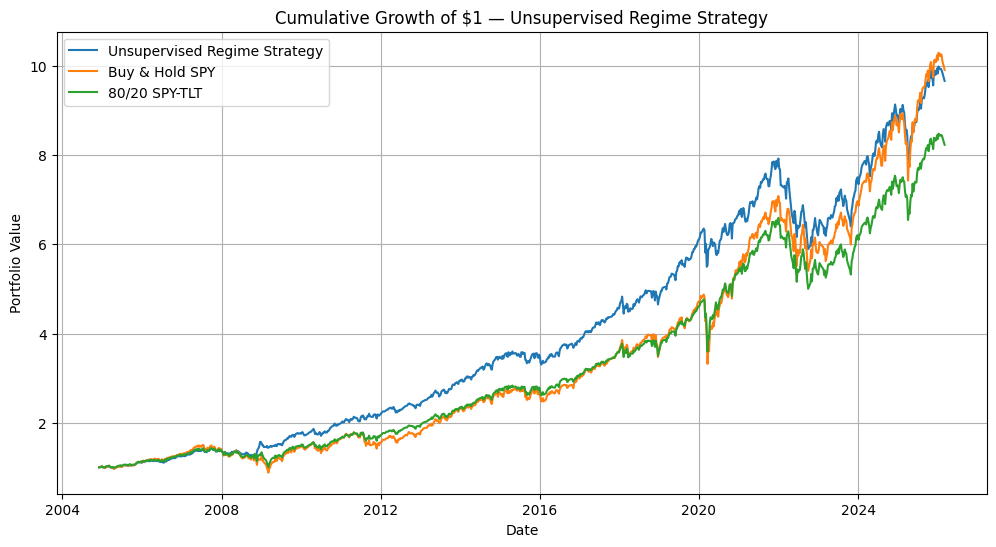

In [84]:
# growth and graphs (test period only)

unsup_plot = unsup_bt.copy()

unsup_plot["growth_unsup"] = cumulative_growth(unsup_plot["strategy_return_unsup"])
unsup_plot["growth_spy"] = cumulative_growth(unsup_plot["benchmark_spy"])
unsup_plot["growth_8020"] = cumulative_growth(unsup_plot["benchmark_80_20"])

plt.figure(figsize=(12, 6))
plt.plot(unsup_plot.index, unsup_plot["growth_unsup"], label="Unsupervised Regime Strategy")
plt.plot(unsup_plot.index, unsup_plot["growth_spy"], label="Buy & Hold SPY")
plt.plot(unsup_plot.index, unsup_plot["growth_8020"], label="80/20 SPY-TLT")
plt.title("Cumulative Growth of $1 — Unsupervised Regime Strategy")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

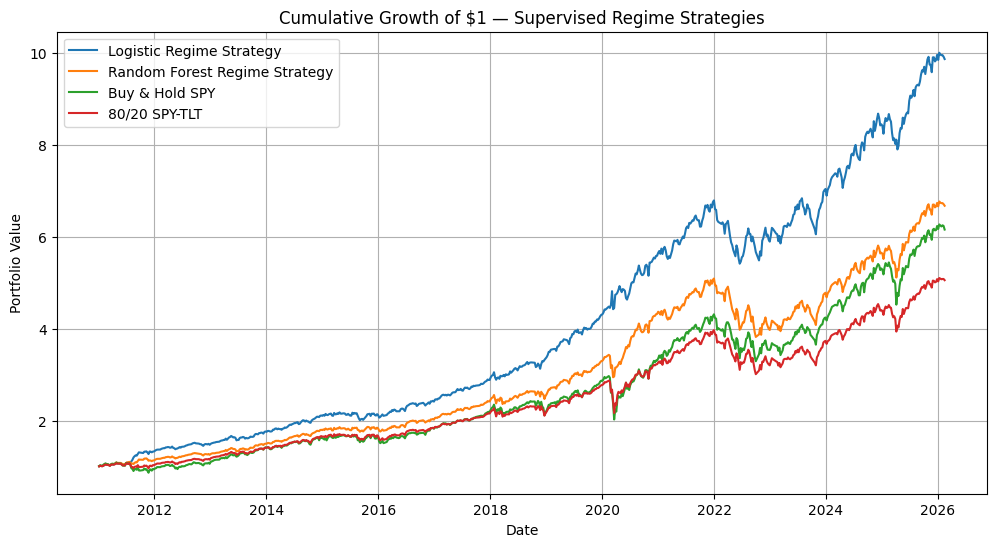

In [86]:
sup_plot = sup_bt.copy()

sup_plot["growth_lr"] = cumulative_growth(sup_plot["strategy_return_lr"])
sup_plot["growth_rf"] = cumulative_growth(sup_plot["strategy_return_rf"])
sup_plot["growth_spy"] = cumulative_growth(sup_plot["benchmark_spy"])
sup_plot["growth_8020"] = cumulative_growth(sup_plot["benchmark_80_20"])

plt.figure(figsize=(12, 6))
plt.plot(sup_plot.index, sup_plot["growth_lr"], label="Logistic Regime Strategy")
plt.plot(sup_plot.index, sup_plot["growth_rf"], label="Random Forest Regime Strategy")
plt.plot(sup_plot.index, sup_plot["growth_spy"], label="Buy & Hold SPY")
plt.plot(sup_plot.index, sup_plot["growth_8020"], label="80/20 SPY-TLT")
plt.title("Cumulative Growth of $1 — Supervised Regime Strategies")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

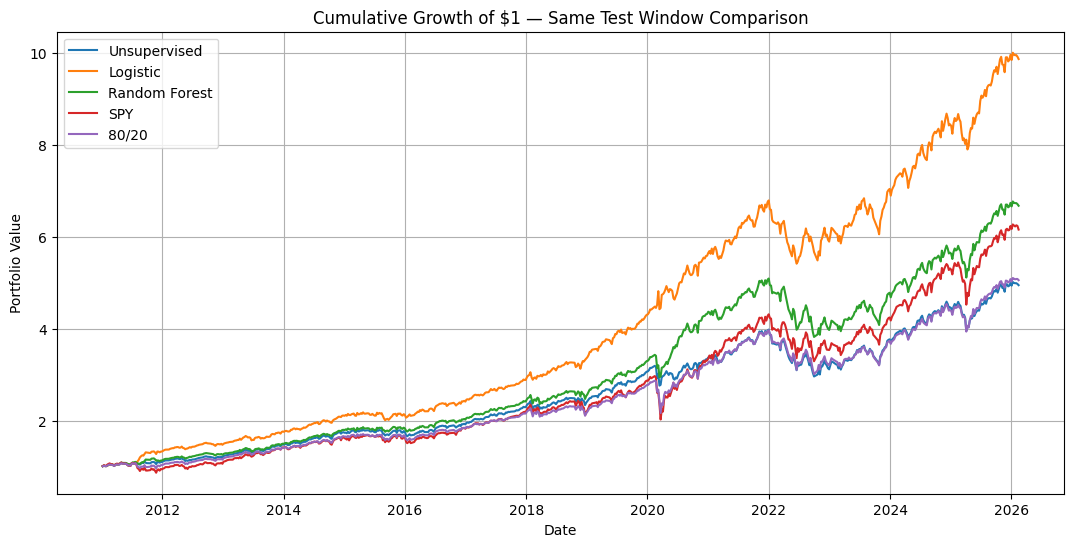

In [88]:
common_start = sup_bt.index.min()
common_end = sup_bt.index.max()

unsup_same = unsup_bt.loc[(unsup_bt.index >= common_start) & (unsup_bt.index <= common_end)].copy()
sup_same = sup_bt.copy()

compare_df = pd.DataFrame(index=sup_same.index)
compare_df["Unsupervised"] = cumulative_growth(unsup_same["strategy_return_unsup"])
compare_df["Logistic"] = cumulative_growth(sup_same["strategy_return_lr"])
compare_df["Random Forest"] = cumulative_growth(sup_same["strategy_return_rf"])
compare_df["SPY"] = cumulative_growth(sup_same["benchmark_spy"])
compare_df["80/20"] = cumulative_growth(sup_same["benchmark_80_20"])

plt.figure(figsize=(13, 6))
for col in compare_df.columns:
    plt.plot(compare_df.index, compare_df[col], label=col)

plt.title("Cumulative Growth of $1 — Same Test Window Comparison")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

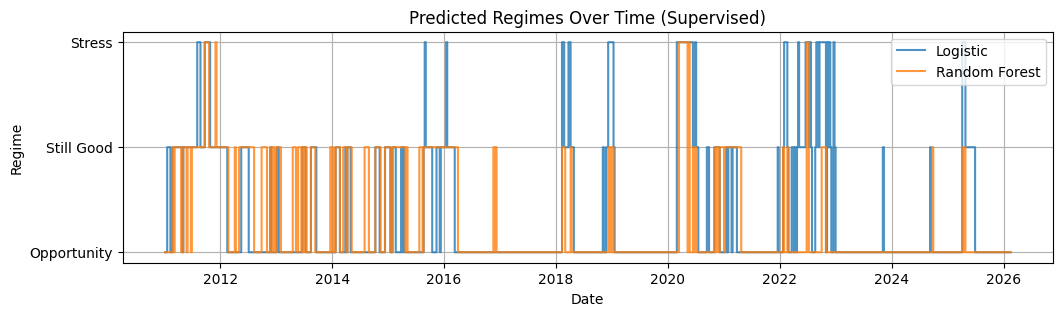

In [90]:
# Map regimes to numeric for plotting
regime_to_num = {
    "Opportunity": 0,
    "Still Good": 1,
    "Stress": 2
}

plot_df = sup_bt.copy()

plot_df["lr_num"] = plot_df["signal_lr"].map(regime_to_num)
plot_df["rf_num"] = plot_df["signal_rf"].map(regime_to_num)

plt.figure(figsize=(12, 3))

plt.plot(plot_df.index, plot_df["lr_num"], drawstyle="steps-post", label="Logistic", alpha=0.8)
plt.plot(plot_df.index, plot_df["rf_num"], drawstyle="steps-post", label="Random Forest", alpha=0.8)

plt.yticks([0, 1, 2], ["Opportunity", "Still Good", "Stress"])

plt.title("Predicted Regimes Over Time (Supervised)")
plt.xlabel("Date")
plt.ylabel("Regime")
plt.legend()
plt.grid(True)

plt.show()

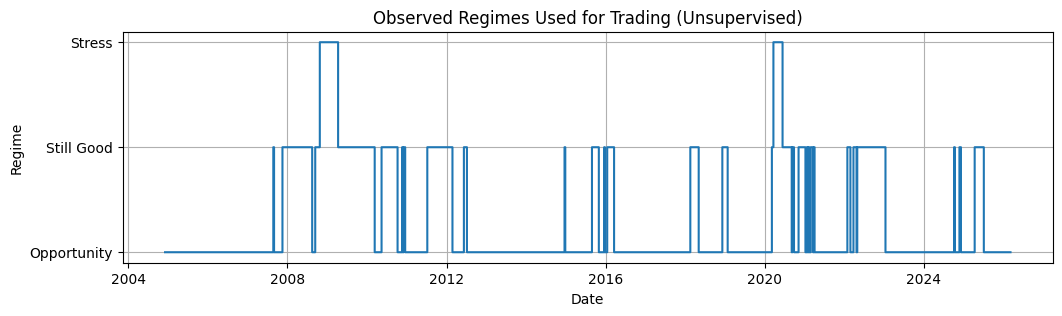

In [92]:
unsup_plot = unsup_bt.copy()

unsup_plot["unsup_num"] = unsup_plot["signal_unsup_std"].map(regime_to_num)

plt.figure(figsize=(12, 3))

plt.plot(unsup_plot.index, unsup_plot["unsup_num"], drawstyle="steps-post", label="Unsupervised")

plt.yticks([0, 1, 2], ["Opportunity", "Still Good", "Stress"])

plt.title("Observed Regimes Used for Trading (Unsupervised)")
plt.xlabel("Date")
plt.ylabel("Regime")
plt.grid(True)

plt.show()

In [94]:
price_cols = {
    "SPY": "SP500_SPY",
    "QQQ": "NASDAQ100_QQQ",
    "TLT": "TREASURY_BOND_TLT",
    "GLD": "GOLD_GLD",
    "XLE": "ENERGY_XLE",
    "XLK": "TECH_XLK",
    "XLU": "UTILITIES_XLU",
    "XLP": "CONSUMER_STAPLES_XLP",
    "XLV": "HEALTHCARE_XLV",
    "XLF": "FINANCIALS_XLF"
}

allocation_map_a = {
    "Opportunity": {"SPY": 0.60, "QQQ": 0.20, "TLT": 0.20, "GLD": 0.00},
    "Still Good": {"SPY": 0.30, "QQQ": 0.20, "TLT": 0.30, "GLD": 0.20},
    "Stress": {"SPY": 0.10, "QQQ": 0.00, "TLT": 0.70, "GLD": 0.20},
}

allocation_map_b = {
    "Opportunity": {"SPY": 0.70, "QQQ": 0.20, "TLT": 0.10, "GLD": 0.00},
    "Still Good": {"SPY": 0.50, "QQQ": 0.00, "TLT": 0.30, "GLD": 0.20},
    "Stress": {"SPY": 0.10, "QQQ": 0.00, "TLT": 0.70, "GLD": 0.20},
}

allocation_map_c = {
    "Opportunity": {"SPY": 0.40, "QQQ": 0.20, "XLK": 0.20, "XLE": 0.10, "TLT": 0.10},
    "Still Good": {"TLT": 0.30, "GLD": 0.20, "XLU": 0.35, "XLP": 0.15},
    "Stress": {"SPY": 0.10, "QQQ": 0.00, "TLT": 0.70, "GLD": 0.20},
}

allocation_map_d = {
    "Opportunity": {"SPY": 0.50, "QQQ": 0.20, "XLK": 0.20, "TLT": 0.10},
    "Still Good": {"TLT": 0.10, "GLD": 0.50, "XLU": 0.15, "XLP": 0.10, "XLV": 0.15},
    "Stress": {"SPY": 0.10, "QQQ": 0.00, "TLT": 0.70, "GLD": 0.20},
}

In [96]:
returns_df = pd.DataFrame(index=backtest_df.index)

for asset_name, col in price_cols.items():
    if col in backtest_df.columns:
        returns_df[f"{asset_name}_return"] = backtest_df[col].pct_change()
    else:
        print(f"Warning: {col} not found in backtest_df")

print("\nReturns df head:")
print(returns_df.head())

print("\nReturns df tail:")
print(returns_df.tail())


Returns df head:
            SPY_return  QQQ_return  TLT_return  GLD_return  XLE_return  \
1995-01-06         NaN         NaN         NaN         NaN         NaN   
1995-01-13    0.014929         NaN         NaN         NaN         NaN   
1995-01-20   -0.004011         NaN         NaN         NaN         NaN   
1995-01-27    0.012084         NaN         NaN         NaN         NaN   
1995-02-03    0.019570         NaN         NaN         NaN         NaN   

            XLK_return  XLU_return  XLP_return  XLV_return  XLF_return  
1995-01-06         NaN         NaN         NaN         NaN         NaN  
1995-01-13         NaN         NaN         NaN         NaN         NaN  
1995-01-20         NaN         NaN         NaN         NaN         NaN  
1995-01-27         NaN         NaN         NaN         NaN         NaN  
1995-02-03         NaN         NaN         NaN         NaN         NaN  

Returns df tail:
            SPY_return  QQQ_return  TLT_return  GLD_return  XLE_return  \
2026-03

In [100]:
for col in returns_df.columns:
    backtest_df[col] = returns_df[col]

print("\nReturn columns now in backtest_df:")
print([col for col in backtest_df.columns if col.endswith("_return")])


Return columns now in backtest_df:
['SPY_return', 'QQQ_return', 'TLT_return', 'GLD_return', 'XLE_return', 'XLK_return', 'XLU_return', 'XLP_return', 'XLV_return', 'XLF_return']


In [104]:
# Safely refresh/add all return columns into backtest_df
for col in returns_df.columns:
    backtest_df[col] = returns_df[col]

# Rebuild strategy subsets so they include the full return set
unsup_bt = backtest_df.dropna(subset=["regime_name"]).copy()
sup_bt = backtest_df.dropna(subset=["actual_regime", "pred_lr", "pred_rf"]).copy()

# Recreate strategy signals
unsup_bt["signal_unsup"] = unsup_bt["regime_name"].shift(1)

unsup_label_map = {
    "Low_Vol": "Opportunity",
    "Mid_Vol": "Still Good",
    "High_Vol": "Stress"
}
unsup_bt["signal_unsup_std"] = unsup_bt["signal_unsup"].map(unsup_label_map)

sup_bt["signal_lr"] = sup_bt["pred_lr"]
sup_bt["signal_rf"] = sup_bt["pred_rf"]

# Drop missing signal rows
unsup_bt = unsup_bt.dropna(subset=["signal_unsup_std"]).copy()
sup_bt = sup_bt.dropna(subset=["signal_lr", "signal_rf"]).copy()

print("\nunsup_bt shape:", unsup_bt.shape)
print("sup_bt shape:", sup_bt.shape)

print("\nReturn columns available in unsup_bt:")
print([c for c in unsup_bt.columns if c.endswith("_return")])

print("\nReturn columns available in sup_bt:")
print([c for c in sup_bt.columns if c.endswith("_return")])


unsup_bt shape: (1054, 59)
sup_bt shape: (757, 59)

Return columns available in unsup_bt:
['SPY_return', 'QQQ_return', 'TLT_return', 'GLD_return', 'XLE_return', 'XLK_return', 'XLU_return', 'XLP_return', 'XLV_return', 'XLF_return']

Return columns available in sup_bt:
['SPY_return', 'QQQ_return', 'TLT_return', 'GLD_return', 'XLE_return', 'XLK_return', 'XLU_return', 'XLP_return', 'XLV_return', 'XLF_return']


In [124]:
def run_allocation_backtest(
    base_df,
    signal_col,
    allocation_map,
    strategy_name,
    benchmark_spy_col="SPY_return",
    benchmark_tlt_col="TLT_return"
):
    df = base_df.copy()

    # Drop old weight / result columns if rerunning
    cols_to_drop = [c for c in df.columns if c.startswith("w_")] + [
        "strategy_return", "benchmark_spy", "benchmark_80_20",
        "strategy_growth", "spy_growth", "growth_8020"
    ]
    cols_to_drop = [c for c in cols_to_drop if c in df.columns]
    df = df.drop(columns=cols_to_drop)

    def get_weights(regime):
        if pd.isna(regime):
            return {}
        if regime not in allocation_map:
            raise ValueError(f"Regime {regime} not found in allocation map")
        return allocation_map[regime]

    weights_df = df[signal_col].map(get_weights).apply(pd.Series).fillna(0.0)
    weights_df = weights_df.add_prefix("w_")

    df = pd.concat([df, weights_df], axis=1)

    weight_cols = list(weights_df.columns)

    # Ensure needed return columns exist
    for col in weight_cols:
        asset_name = col.replace("w_", "")
        return_col = f"{asset_name}_return"
        if return_col not in df.columns:
            df[return_col] = np.nan
        # do NOT fill missing returns with 0 here anymore

    # Check weight sums
    weight_sums = df[weight_cols].sum(axis=1)
    if not np.allclose(weight_sums, 1.0):
        print(f"Warning: some {strategy_name} weights do not sum to 1.0")
        print(weight_sums.value_counts())

    # Old simple logic kept for reference
    '''
    df["strategy_return"] = 0.0
    for col in weight_cols:
        asset_name = col.replace("w_", "")
        df["strategy_return"] += df[col] * df[f"{asset_name}_return"]
    '''

    # New logic: re-scale weights across available assets
    strategy_returns = []

    for idx, row in df.iterrows():
        row_return = 0.0
        valid_weights = {}

        # Keep only assets with non-missing returns
        for col in weight_cols:
            asset_name = col.replace("w_", "")
            return_col = f"{asset_name}_return"

            if return_col in df.columns and pd.notna(row[return_col]):
                valid_weights[asset_name] = row[col]

        # If nothing available, return 0
        if len(valid_weights) == 0:
            strategy_returns.append(0.0)
            continue

        # Re-scale weights to sum to 1 across available assets
        total_weight = sum(valid_weights.values())
        if total_weight == 0:
            strategy_returns.append(0.0)
            continue

        for asset_name, w in valid_weights.items():
            return_col = f"{asset_name}_return"
            row_return += (w / total_weight) * row[return_col]

        strategy_returns.append(row_return)

    df["strategy_return"] = strategy_returns

    # Benchmarks
    df["benchmark_spy"] = df[benchmark_spy_col]
    df["benchmark_80_20"] = 0.80 * df[benchmark_spy_col] + 0.20 * df[benchmark_tlt_col]

    # Growth series
    df["strategy_growth"] = cumulative_growth(df["strategy_return"])
    df["spy_growth"] = cumulative_growth(df["benchmark_spy"])
    df["growth_8020"] = cumulative_growth(df["benchmark_80_20"])

    summary = pd.DataFrame([
        summarize_performance(df["strategy_return"], strategy_name),
        summarize_performance(df["benchmark_spy"], f"Buy & Hold SPY ({strategy_name})"),
        summarize_performance(df["benchmark_80_20"], f"80/20 SPY-TLT ({strategy_name})")
    ])

    return df, summary

In [126]:
results = {}

allocation_tests = {
    "Current": allocation_map_a,
    "Aggressive Bull": allocation_map_b,
    "Sector Tilt": allocation_map_c,
    "Defensive Rotation": allocation_map_d
}

for test_name, alloc in allocation_tests.items():
    # Unsupervised
    unsup_res, unsup_summary = run_allocation_backtest(
        base_df=unsup_bt,
        signal_col="signal_unsup_std",
        allocation_map=alloc,
        strategy_name=f"Unsupervised - {test_name}"
    )
    unsup_summary["Allocation Test"] = test_name
    unsup_summary["Model Type"] = "Unsupervised"

    # Logistic
    lr_res, lr_summary = run_allocation_backtest(
        base_df=sup_bt,
        signal_col="signal_lr",
        allocation_map=alloc,
        strategy_name=f"Logistic - {test_name}"
    )
    lr_summary["Allocation Test"] = test_name
    lr_summary["Model Type"] = "Logistic"

    # Random Forest
    rf_res, rf_summary = run_allocation_backtest(
        base_df=sup_bt,
        signal_col="signal_rf",
        allocation_map=alloc,
        strategy_name=f"Random Forest - {test_name}"
    )
    rf_summary["Allocation Test"] = test_name
    rf_summary["Model Type"] = "Random Forest"

    results[test_name] = {
        "unsup": (unsup_res, unsup_summary),
        "lr": (lr_res, lr_summary),
        "rf": (rf_res, rf_summary),
    }

comparison = pd.concat(
    [
        results[test_name]["unsup"][1]
        for test_name in results
    ] +
    [
        results[test_name]["lr"][1]
        for test_name in results
    ] +
    [
        results[test_name]["rf"][1]
        for test_name in results
    ],
    ignore_index=True
)

print(comparison)

                                             Strategy  Annualized Return  \
0                              Unsupervised - Current           0.118507   
1             Buy & Hold SPY (Unsupervised - Current)           0.119801   
2              80/20 SPY-TLT (Unsupervised - Current)           0.109591   
3                      Unsupervised - Aggressive Bull           0.120126   
4     Buy & Hold SPY (Unsupervised - Aggressive Bull)           0.119801   
5      80/20 SPY-TLT (Unsupervised - Aggressive Bull)           0.109591   
6                          Unsupervised - Sector Tilt           0.119360   
7         Buy & Hold SPY (Unsupervised - Sector Tilt)           0.119801   
8          80/20 SPY-TLT (Unsupervised - Sector Tilt)           0.109591   
9                   Unsupervised - Defensive Rotation           0.128262   
10  Buy & Hold SPY (Unsupervised - Defensive Rotat...           0.119801   
11  80/20 SPY-TLT (Unsupervised - Defensive Rotation)           0.109591   
12          

In [128]:
comparison_sorted = comparison.sort_values(
    by=["Model Type", "Sharpe Ratio", "Annualized Return"],
    ascending=[True, False, False]
)

print(comparison_sorted)

                                             Strategy  Annualized Return  \
18                             Logistic - Sector Tilt           0.183138   
15                         Logistic - Aggressive Bull           0.180795   
21                      Logistic - Defensive Rotation           0.186356   
12                                 Logistic - Current           0.167389   
14                 80/20 SPY-TLT (Logistic - Current)           0.117681   
17         80/20 SPY-TLT (Logistic - Aggressive Bull)           0.117681   
20             80/20 SPY-TLT (Logistic - Sector Tilt)           0.117681   
23      80/20 SPY-TLT (Logistic - Defensive Rotation)           0.117681   
13                Buy & Hold SPY (Logistic - Current)           0.132914   
16        Buy & Hold SPY (Logistic - Aggressive Bull)           0.132914   
19            Buy & Hold SPY (Logistic - Sector Tilt)           0.132914   
22     Buy & Hold SPY (Logistic - Defensive Rotation)           0.132914   
30          

In [129]:
strategy_only = comparison[
    ~comparison["Strategy"].str.contains("Buy & Hold|80/20", regex=True)
].copy()

print(strategy_only.sort_values(
    by=["Sharpe Ratio", "Annualized Return"],
    ascending=[False, False]
))

                              Strategy  Annualized Return  \
18              Logistic - Sector Tilt           0.183138   
15          Logistic - Aggressive Bull           0.180795   
21       Logistic - Defensive Rotation           0.186356   
12                  Logistic - Current           0.167389   
30         Random Forest - Sector Tilt           0.176643   
33  Random Forest - Defensive Rotation           0.172707   
27     Random Forest - Aggressive Bull           0.158013   
24             Random Forest - Current           0.142044   
0               Unsupervised - Current           0.118507   
9    Unsupervised - Defensive Rotation           0.128262   
3       Unsupervised - Aggressive Bull           0.120126   
6           Unsupervised - Sector Tilt           0.119360   

    Annualized Volatility  Sharpe Ratio  Max Drawdown     Allocation Test  \
18               0.104836      1.746896     -0.139674         Sector Tilt   
15               0.104482      1.730392     -0.18792

In [136]:
train_cutoff = "2015-12-31"
train_bt = unsup_bt.loc[unsup_bt.index <= train_cutoff].copy()

def build_dynamic_allocation_map(train_df, regime_col="signal_unsup_std", asset_cols=None, top_n=4):
    if asset_cols is None:
        asset_cols = [
            "SPY_return", "QQQ_return", "TLT_return", "GLD_return",
            "XLE_return", "XLK_return", "XLU_return", "XLP_return",
            "XLV_return", "XLF_return"
        ]

    allocation_map = {}

    for regime in sorted(train_df[regime_col].dropna().unique()):
        regime_slice = train_df[train_df[regime_col] == regime]

        scores = {}
        for col in asset_cols:
            if col not in regime_slice.columns:
                scores[col] = 0.0
                continue

            series = regime_slice[col].dropna()
            if len(series) < 10:
                scores[col] = 0.0
                continue

            mean_ret = series.mean()
            vol = series.std()
            score = 0.0 if (vol == 0 or np.isnan(vol)) else mean_ret / vol
            scores[col] = max(score, 0.0)

        score_series = pd.Series(scores).sort_values(ascending=False)
        score_series = score_series[score_series > 0].head(top_n)

        if len(score_series) == 0:
            weights = {
                "SPY": 0.25,
                "QQQ": 0.25,
                "TLT": 0.25,
                "GLD": 0.25
            }
        else:
            weights = (score_series / score_series.sum()).to_dict()
            weights = {k.replace("_return", ""): v for k, v in weights.items()}

        allocation_map[regime] = weights

    return allocation_map

def inspect_regime_scores(train_df, regime, regime_col="signal_unsup_std", asset_cols=None):
    if asset_cols is None:
        asset_cols = [
            "SPY_return", "QQQ_return", "TLT_return", "GLD_return",
            "XLE_return", "XLK_return", "XLU_return", "XLP_return",
            "XLV_return", "XLF_return"
        ]

    regime_slice = train_df[train_df[regime_col] == regime]
    rows = []

    for col in asset_cols:
        if col not in regime_slice.columns:
            continue

        series = regime_slice[col].dropna()
        mean_ret = series.mean()
        vol = series.std()
        score = 0.0 if (vol == 0 or np.isnan(vol)) else mean_ret / vol

        rows.append({
            "asset": col.replace("_return", ""),
            "mean_return": mean_ret,
            "volatility": vol,
            "score": score
        })

    return pd.DataFrame(rows).sort_values("score", ascending=False)

print(inspect_regime_scores(train_bt, regime="Opportunity"))
print(inspect_regime_scores(train_bt, regime="Still Good"))
print(inspect_regime_scores(train_bt, regime="Stress"))

score_opp = inspect_regime_scores(train_bt, regime="Opportunity").copy()
score_mid = inspect_regime_scores(train_bt, regime="Still Good").copy()
score_str = inspect_regime_scores(train_bt, regime="Stress").copy()

score_opp["regime"] = "Opportunity"
score_mid["regime"] = "Still Good"
score_str["regime"] = "Stress"

score_df = pd.concat([score_opp, score_mid, score_str], axis=0)
print(score_df.head())

  asset  mean_return  volatility     score
8   XLV     0.002790    0.015514  0.179869
7   XLP     0.002252    0.013419  0.167786
6   XLU     0.002504    0.018112  0.138225
0   SPY     0.002075    0.016067  0.129142
1   QQQ     0.002367    0.020733  0.114184
5   XLK     0.001905    0.019694  0.096711
2   TLT     0.001461    0.016246  0.089909
9   XLF     0.001720    0.020830  0.082567
4   XLE     0.002305    0.028515  0.080833
3   GLD     0.001037    0.023165  0.044758
  asset  mean_return  volatility     score
7   XLP     0.003601    0.017946  0.200637
1   QQQ     0.003917    0.029149  0.134392
8   XLV     0.003040    0.023833  0.127540
5   XLK     0.003392    0.028196  0.120318
0   SPY     0.003000    0.027329  0.109759
6   XLU     0.002541    0.024576  0.103406
3   GLD     0.002969    0.029858  0.099436
4   XLE     0.003520    0.039668  0.088725
2   TLT     0.001564    0.020947  0.074668
9   XLF     0.002046    0.046517  0.043992
  asset  mean_return  volatility     score
2   TLT    

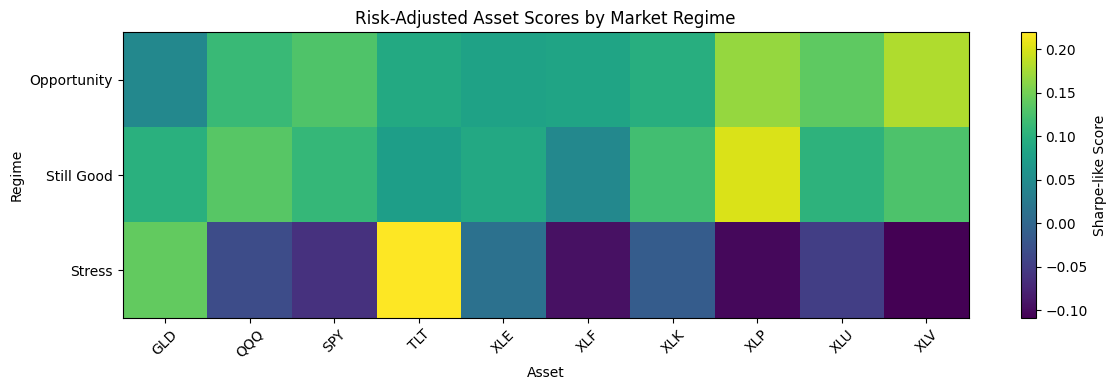

In [131]:
import matplotlib.pyplot as plt
import pandas as pd

heatmap_df = score_df.pivot(index="regime", columns="asset", values="score")

plt.figure(figsize=(12, 4))
plt.imshow(heatmap_df, aspect="auto")
plt.colorbar(label="Sharpe-like Score")

plt.xticks(range(len(heatmap_df.columns)), heatmap_df.columns, rotation=45)
plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)

plt.title("Risk-Adjusted Asset Scores by Market Regime")
plt.xlabel("Asset")
plt.ylabel("Regime")
plt.tight_layout()
plt.show()

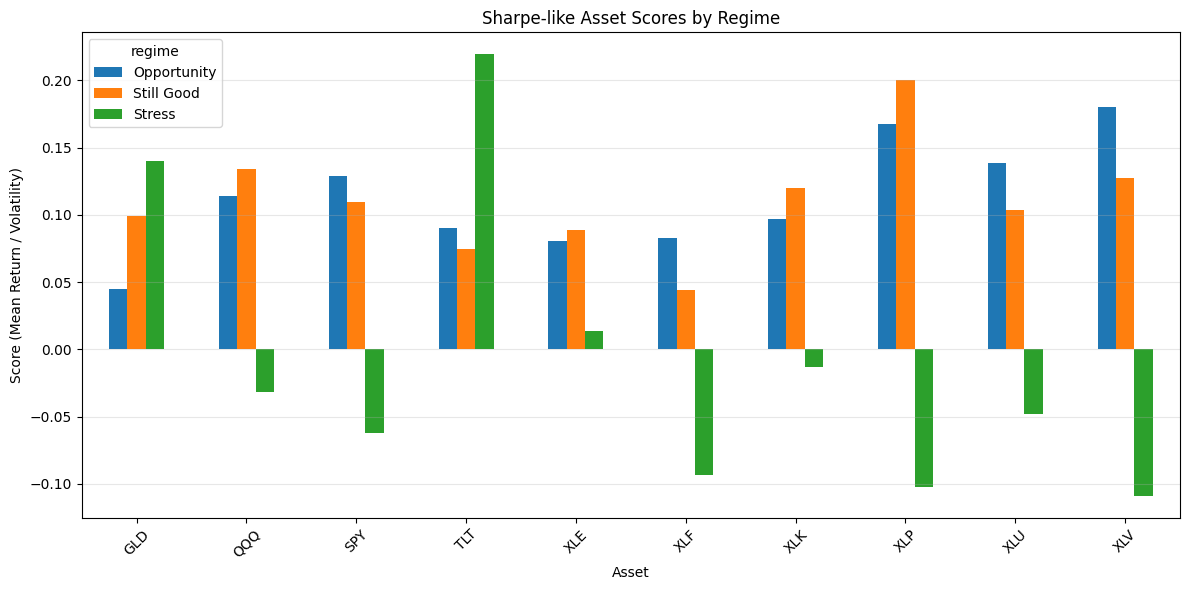

In [132]:
pivot_scores = score_df.pivot(index="asset", columns="regime", values="score")

pivot_scores.plot(kind="bar", figsize=(12, 6))
plt.title("Sharpe-like Asset Scores by Regime")
plt.ylabel("Score (Mean Return / Volatility)")
plt.xlabel("Asset")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

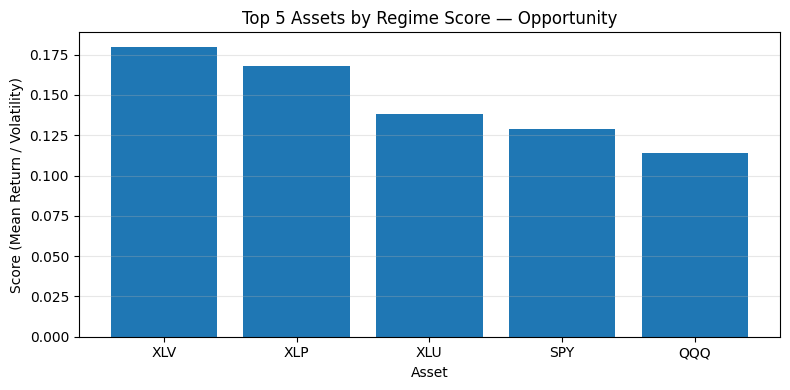

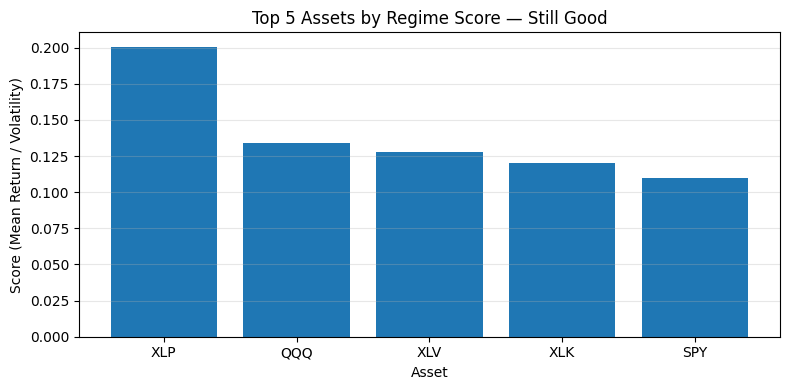

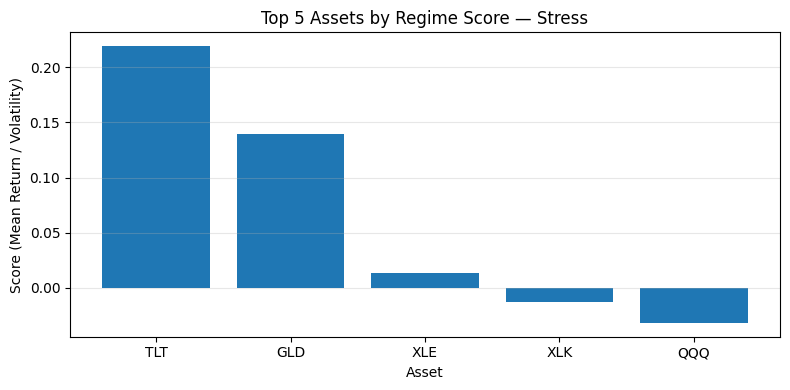

In [133]:
import matplotlib.pyplot as plt

for reg in ["Opportunity", "Still Good", "Stress"]:
    temp = score_df[score_df["regime"] == reg].sort_values("score", ascending=False).head(5)

    plt.figure(figsize=(8, 4))
    plt.bar(temp["asset"], temp["score"])
    plt.title(f"Top 5 Assets by Regime Score — {reg}")
    plt.ylabel("Score (Mean Return / Volatility)")
    plt.xlabel("Asset")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [138]:
# Dynamic regime allocation map
# Learns asset weights from training data only

def build_dynamic_allocation_map(train_df, regime_col, asset_cols=None, top_n=4):
    if asset_cols is None:
        asset_cols = [
            "SPY_return", "QQQ_return", "TLT_return", "GLD_return",
            "XLE_return", "XLK_return", "XLU_return", "XLP_return",
            "XLV_return", "XLF_return"
        ]

    allocation_map = {}

    for regime in sorted(train_df[regime_col].dropna().unique()):
        regime_slice = train_df[train_df[regime_col] == regime]

        scores = {}
        for col in asset_cols:
            if col not in regime_slice.columns:
                continue

            series = regime_slice[col].dropna()
            if len(series) < 10:
                scores[col] = 0.0
                continue

            mean_ret = series.mean()
            vol = series.std()

            if pd.isna(vol) or vol == 0:
                score = 0.0
            else:
                score = mean_ret / vol

            scores[col] = max(score, 0.0)

        score_series = pd.Series(scores).sort_values(ascending=False)

        # keep only top N positive-score assets
        score_series = score_series[score_series > 0].head(top_n)

        # fallback if nothing scores positive
        if len(score_series) == 0:
            weights = {
                "SPY": 0.25,
                "QQQ": 0.25,
                "TLT": 0.25,
                "GLD": 0.25
            }
        else:
            weights = (score_series / score_series.sum()).to_dict()
            weights = {k.replace("_return", ""): v for k, v in weights.items()}

        allocation_map[regime] = weights

    return allocation_map

In [140]:
# Training windows for dynamic maps
train_cutoff = "2015-12-31"

unsup_train = unsup_bt.loc[unsup_bt.index <= train_cutoff].copy()
sup_train = sup_bt.loc[sup_bt.index <= train_cutoff].copy()

dynamic_map_unsup = build_dynamic_allocation_map(
    train_df=unsup_train,
    regime_col="signal_unsup_std",
    top_n=4
)

dynamic_map_lr = build_dynamic_allocation_map(
    train_df=sup_train,
    regime_col="signal_lr",
    top_n=4
)

dynamic_map_rf = build_dynamic_allocation_map(
    train_df=sup_train,
    regime_col="signal_rf",
    top_n=4
)

print("Dynamic map - Unsupervised")
print(dynamic_map_unsup)
print("\nDynamic map - Logistic")
print(dynamic_map_lr)
print("\nDynamic map - Random Forest")
print(dynamic_map_rf)

Dynamic map - Unsupervised
{'Opportunity': {'XLV': 0.29245911322991214, 'XLP': 0.27281332017618326, 'XLU': 0.2247484838107994, 'SPY': 0.20997908278310515}, 'Still Good': {'XLP': 0.3442117727453429, 'QQQ': 0.23056204390063187, 'XLV': 0.2188082109161398, 'XLK': 0.2064179724378855}, 'Stress': {'TLT': 0.5883327249294483, 'GLD': 0.3754632975961598, 'XLE': 0.03620397747439183}}

Dynamic map - Logistic
{'Opportunity': {'XLV': 0.3054452442482167, 'XLF': 0.2374420693641302, 'SPY': 0.22892946616183305, 'QQQ': 0.22818322022582}, 'Still Good': {'XLP': 0.31526477332056313, 'XLU': 0.26693840311566525, 'XLV': 0.2312554722388627, 'QQQ': 0.18654135132490893}, 'Stress': {'SPY': 0.25, 'QQQ': 0.25, 'TLT': 0.25, 'GLD': 0.25}}

Dynamic map - Random Forest
{'Opportunity': {'XLV': 0.31417496348646967, 'QQQ': 0.23759648223832644, 'SPY': 0.23391484270193677, 'XLK': 0.21431371157326704}, 'Still Good': {'TLT': 0.3508964203487858, 'XLP': 0.2951526579290993, 'XLU': 0.20336170797602268, 'XLV': 0.15058921374609205}, 

In [142]:
dyn_unsup_df, dyn_unsup_summary = run_allocation_backtest(
    base_df=unsup_bt,
    signal_col="signal_unsup_std",
    allocation_map=dynamic_map_unsup,
    strategy_name="Dynamic Unsupervised"
)

dyn_lr_df, dyn_lr_summary = run_allocation_backtest(
    base_df=sup_bt,
    signal_col="signal_lr",
    allocation_map=dynamic_map_lr,
    strategy_name="Dynamic Logistic"
)

dyn_rf_df, dyn_rf_summary = run_allocation_backtest(
    base_df=sup_bt,
    signal_col="signal_rf",
    allocation_map=dynamic_map_rf,
    strategy_name="Dynamic Random Forest"
)

dynamic_summary = pd.concat(
    [dyn_unsup_summary, dyn_lr_summary, dyn_rf_summary],
    ignore_index=True
)

print(dynamic_summary)

                                 Strategy  Annualized Return  \
0                    Dynamic Unsupervised           0.133413   
1   Buy & Hold SPY (Dynamic Unsupervised)           0.119801   
2    80/20 SPY-TLT (Dynamic Unsupervised)           0.109591   
3                        Dynamic Logistic           0.176902   
4       Buy & Hold SPY (Dynamic Logistic)           0.132914   
5        80/20 SPY-TLT (Dynamic Logistic)           0.117681   
6                   Dynamic Random Forest           0.189215   
7  Buy & Hold SPY (Dynamic Random Forest)           0.132914   
8   80/20 SPY-TLT (Dynamic Random Forest)           0.117681   

   Annualized Volatility  Sharpe Ratio  Max Drawdown  
0               0.128896      1.035044     -0.177069  
1               0.170133      0.704156     -0.413713  
2               0.131838      0.831252     -0.296071  
3               0.126300      1.400646     -0.167136  
4               0.161942      0.820751     -0.318290  
5               0.126865     

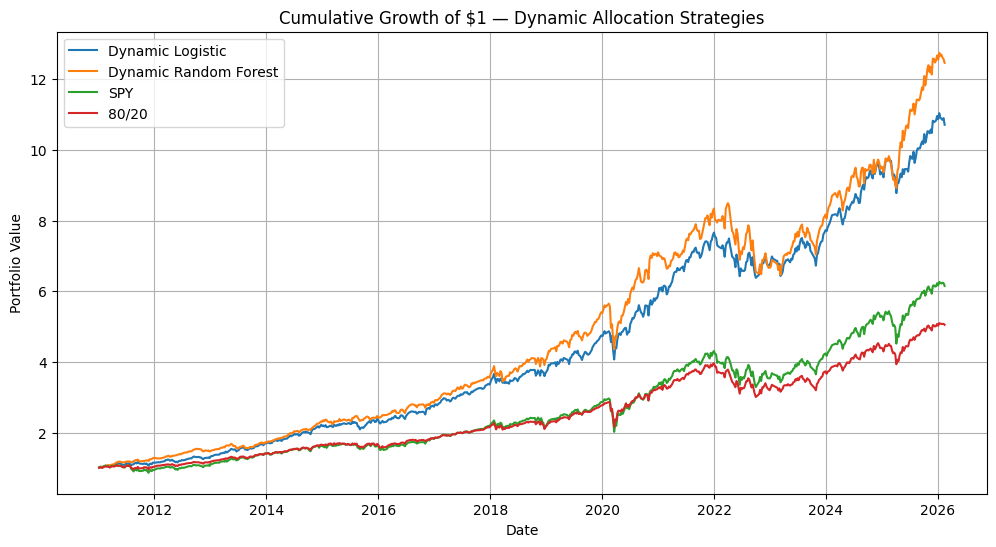

In [144]:
plt.figure(figsize=(12, 6))
plt.plot(dyn_lr_df.index, dyn_lr_df["strategy_growth"], label="Dynamic Logistic")
plt.plot(dyn_rf_df.index, dyn_rf_df["strategy_growth"], label="Dynamic Random Forest")
plt.plot(dyn_lr_df.index, dyn_lr_df["spy_growth"], label="SPY")
plt.plot(dyn_lr_df.index, dyn_lr_df["growth_8020"], label="80/20")
plt.title("Cumulative Growth of $1 — Dynamic Allocation Strategies")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

,SPY_return,QQQ_return,SPY_momentum_12,VIX_change,SPY_vol_4,SPY_vol_12,yield_spread,SPY_return_lag1,SPY_return_lag2,SPY_return_lag3,...,yield_spread_lag4,yield_spread_lag5,current_regime,next_regime,target,actual_next_regime,persist_pred,2l_base_pred,2l_pred,l1_pred
2021-01-08,0.019739,0.016861,0.102494,-0.052308,0.008456,0.029673,0.99,0.013225,-0.000487,0.012159,...,0.79,0.81,Low_Vol,Mid_Vol,change,Mid_Vol,Low_Vol,Low_Vol,Low_Vol,no change
2021-01-15,-0.014583,-0.022474,0.091161,0.128943,0.015247,0.030220,0.98,0.019739,0.013225,-0.000487,...,0.82,0.79,Mid_Vol,Low_Vol,change,Low_Vol,Mid_Vol,Mid_Vol,Mid_Vol,no change
2021-01-22,0.019111,0.043481,0.177535,-0.099836,0.016238,0.022756,0.97,-0.014583,0.019739,0.013225,...,0.81,0.82,Low_Vol,Mid_Vol,change,Mid_Vol,Low_Vol,Low_Vol,Low_Vol,no change
2021-01-29,-0.033457,-0.033372,0.061365,0.510269,0.026241,0.018092,1.00,0.019111,-0.014583,0.019739,...,0.80,0.81,Mid_Vol,Low_Vol,change,Low_Vol,Mid_Vol,Mid_Vol,Mid_Vol,no change
2021-02-05,0.047667,0.053408,0.087302,-0.369296,0.035970,0.021427,1.10,-0.033457,0.019111,-0.014583,...,0.99,0.80,Low_Vol,Low_Vol,no change,Low_Vol,Low_Vol,Low_Vol,Low_Vol,no change
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-16,-0.003472,-0.008601,0.024295,0.094548,0.013040,0.015438,0.65,0.015955,-0.010343,0.014282,...,0.68,0.67,Low_Vol,Low_Vol,no change,Low_Vol,Low_Vol,Low_Vol,Low_Vol,no change
2026-01-23,-0.003513,0.002350,0.013498,0.014502,0.011335,0.015430,0.64,-0.003472,0.015955,-0.010343,...,0.68,0.68,Low_Vol,Low_Vol,no change,Low_Vol,Low_Vol,Low_Vol,Low_Vol,no change
2026-01-30,0.003975,-0.001365,0.034345,0.083903,0.009181,0.014418,0.74,-0.003513,-0.003472,0.015955,...,0.72,0.68,Low_Vol,Low_Vol,no change,Low_Vol,Low_Vol,Low_Vol,Low_Vol,no change
2026-02-06,-0.001951,-0.019650,0.030852,0.168005,0.003552,0.014482,0.72,0.003975,-0.003513,-0.003472,...,0.64,0.72,Low_Vol,Low_Vol,no change,Low_Vol,Low_Vol,Low_Vol,Low_Vol,no change


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=059a5e93-4459-411b-9a58-2a578fd7a892' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>